In [ ]:
import seaborn as sns
import scanpy as sc
import numpy as np
import pandas as pd
import yaml

In [ ]:
masked_results_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/results_new-masked/all_candidates.csv"
unmasked_results_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/results_new/all_candidates.csv"
annotation_config_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/generative_modeling/conditional_flow_matching/config/annotation/default.yaml"
h5ad_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/gdrive/ds_HID01_logicle_100k_UMAP_ann.h5ad"


In [3]:
with open(annotation_config_path, "r") as fb:
    annotation_config = yaml.safe_load(fb)
protocol_columns = annotation_config["protocol_columns"]
print(f"{protocol_columns=}")

protocol_columns=['740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'o2_[%]', 'days_of_culture']


In [4]:
masked_res_df = pd.read_csv(masked_results_path, index_col=0)
unmasked_res_df = pd.read_csv(unmasked_results_path, index_col=0)
res_df = pd.concat((masked_res_df, unmasked_res_df))

# parse column
target_ct = res_df.index.map(lambda e: e.split(":")[0])
run_id = res_df.index.map(lambda e: e.split(":")[1])
sample_id = res_df.index.map(lambda e: e.split(":")[2])

# construct index
index_df = pd.DataFrame(
    {
        "target_ct": target_ct,
        "run_id": run_id,
        "sample_id": sample_id
    }
)
midx = pd.MultiIndex.from_frame(index_df)

res_df.index = midx
res_df

740-yp_[µm]    mtg_[µm]  \
target_ct run_id                       sample_id                            
MgkPro    2026-01-21_18-37-58_02c211a6 0             5.255661  389.431200   
                                       1             5.893735   70.920090   
                                       2             4.075903   42.403410   
                                       3             4.808934   66.075714   
                                       4             5.291095   55.533234   
...                                                       ...         ...   
          2026-01-21_18-21-31_e65f06d5 120           4.742057  114.453460   
                                       121           5.589697  147.114260   
                                       122           4.619626  142.696490   
                                       123           4.209705  187.589300   
                                       124           4.762968  148.481140   

                                                  rhflt3l_[ng_ml]  \
target_ct run_id                       sample_id                    
MgkPro    2026-01-21_18-37-58_02c211a6 0                 1.928358   
                                       1                15.685903   
                                       2                26.332184   
                                       3                13.544823   
                                       4                22.751110   
...                                                           ...   
          2026-01-21_18-21-31_e65f06d5 120              10.321251   
                                       121               4.884870   
                                       122              10.192080   
                                       123               5.827748   
                                       124              15.872105   

                                                  gm-csf_[ng_ml]  tpo_[ng_ml]  \
target_ct run_id                       sample_id                                
MgkPro    2026-01-21_18-37-58_02c211a6 0               31.852552     0.875914   
                                       1               11.334117     2.606867   
                                       2               12.655028     3.770362   
                                       3                9.513528     0.098438   
                                       4                4.414666     3.025789   
...                                                          ...          ...   
          2026-01-21_18-21-31_e65f06d5 120              6.555941     2.883199   
                                       121             33.879990     2.170457   
                                       122              8.624926     2.967821   
                                       123              8.383217     3.030591   
                                       124              2.324983     2.155711   

                                                    sr1_[nm]  um171_[nm]  \
target_ct run_id                       sample_id                           
MgkPro    2026-01-21_18-37-58_02c211a6 0           564.83690    1.651174   
                                       1          2618.23340  344.870060   
                                       2           904.82574    0.000000   
                                       3           103.38541  357.637200   
                                       4           192.31995  783.979430   
...                                                      ...         ...   
          2026-01-21_18-21-31_e65f06d5 120        1648.84060  957.972050   
                                       121         206.78383    2.913209   
                                       122         129.22325    0.000000   
                                       123         446.52744  908.140800   
                                       124        1563.69900  532.220700   

                                                  um729_[µm]  scf_[ng_ml]  \
target_ct run_id              

In [5]:
ct_thresholds_dict = {
    "EryPro": 0.3,
    "HSCs": 0.15,
    "MgkPro": 0.2,
}

ct2df = {}

target_cell_types_list = res_df.index.get_level_values("target_ct").unique()
for target_ct in target_cell_types_list:
    # sort by cell type proportion
    ct_df = res_df.loc[target_ct]
    ct_prop_col = f"{target_ct}_prop"
    ct_df = ct_df.sort_values(ct_prop_col, ascending=False)
    # filter results with cell type threshold
    threshold = ct_thresholds_dict[target_ct]
    ct_df = ct_df[ct_df[ct_prop_col]>threshold]
    ct2df[target_ct] = ct_df
    print(f"{target_ct}->{ct_df.shape[0]}")


MgkPro->13
HSCs->270
EryPro->661


In [6]:
ct2protocols = {}
ct2unique_protocols = {}
for ct, df in ct2df.items():
    protocols_df = df[protocol_columns]
    unique_protocols = np.unique(protocols_df.values, axis=0)
    unique_protocols_df = pd.DataFrame({
        k: unique_protocols[:, v] for v, k in enumerate(protocol_columns) 
    })
    ct2protocols[ct] = protocols_df
    ct2unique_protocols[ct] = unique_protocols_df
    print(f"{ct}->{unique_protocols.shape[0]}")

MgkPro->11
HSCs->241
EryPro->661


In [7]:
protocol_columns

['740-yp_[µm]',
 'mtg_[µm]',
 'rhflt3l_[ng_ml]',
 'gm-csf_[ng_ml]',
 'tpo_[ng_ml]',
 'sr1_[nm]',
 'um171_[nm]',
 'um729_[µm]',
 'scf_[ng_ml]',
 'butyzamide_[nm]',
 'retinoic_acid_[µm]',
 'ldl_[ng_ml]',
 'il3_[ng_ml]',
 'o2_[%]',
 'days_of_culture']

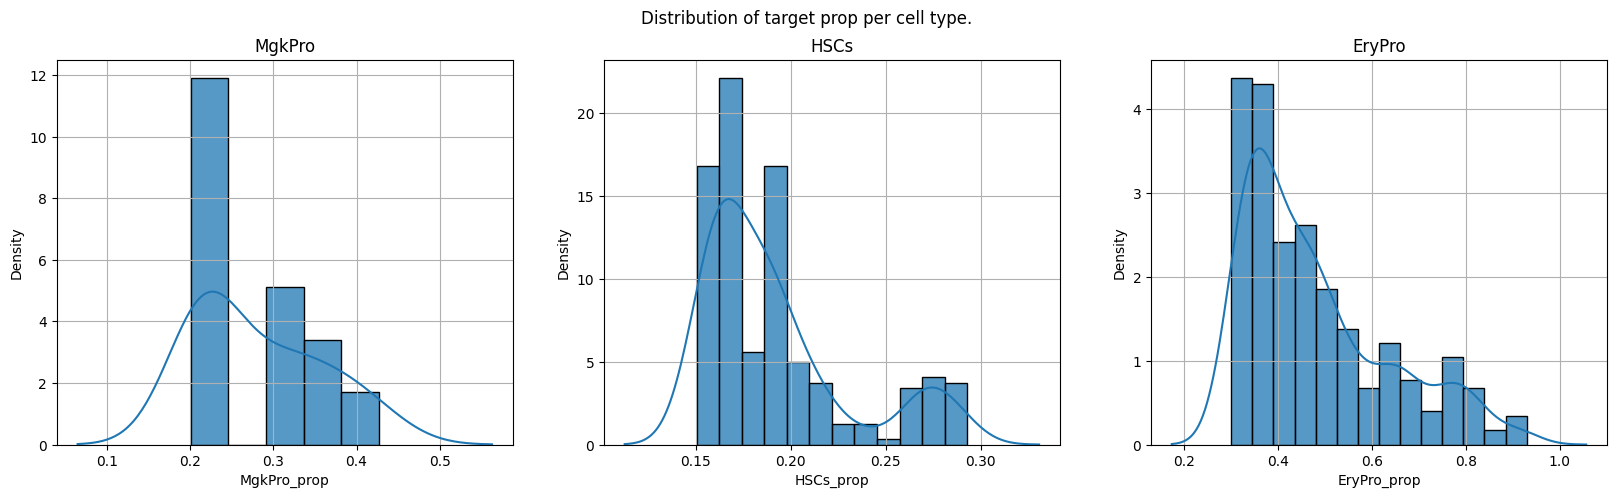

In [15]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, len(target_cell_types_list), figsize=(20, 5))
fig.suptitle("Distribution of target prop per cell type.")
for idx, ct in enumerate(target_cell_types_list):
    ct_prop_col =  f"{ct}_prop"
    ax[idx].set_title(ct)
    sns.histplot(ct2df[ct][ct_prop_col], stat="density", ax=ax[idx])
    sns.kdeplot(ct2df[ct][ct_prop_col], ax=ax[idx])
    ax[idx].grid(True)

In [ ]:
adata = sc.read_h5ad(h5ad_path)
adata

In [9]:
jobs = []
OUT_FILE = f"../experiments/jobs_selected.txt"
for ct, df in ct2df.items():
    df = df.iloc[:20] if 20 < df.shape[0] else df
    df = df.drop_duplicates()
    
    for run, idx in df.index:
        jobs.append(f"{ct} {run} {idx}")
with open(OUT_FILE, "w") as f:
    f.write("\n".join(jobs))